# Titanic Survival Prediction Logistic Regression

In [26]:
# Cell 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Set plot style for cleaner charts
sns.set_theme(style='whitegrid')
%matplotlib inline

In [27]:
# Cell 3
# Load the Titanic training dataset
train_data = pd.read_csv('train.csv')
print(f'Dataset shape: {train_data.shape}')
train_data.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


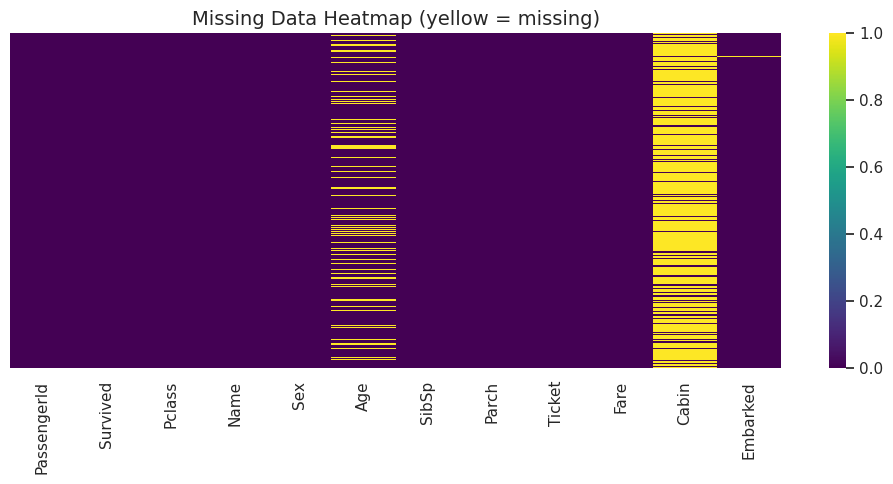

Missing value counts:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [28]:
# Cell 4
# Visualize missing data as a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(train_data.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap (yellow = missing)', fontsize=14)
plt.tight_layout()
plt.show()

print('Missing value counts:')
print(train_data.isnull().sum())

In [29]:
# Cell 5
# Fill missing Age with median (robust to outliers)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())

# Fill missing Embarked with mode (most frequent value)
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

# Drop Cabin (77% missing), Name, Ticket, PassengerId (identifiers)
train_data.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

print('Missing values after handling:')
print(train_data.isnull().sum())
train_data.head()

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


**Cell 6**

### Exploratory Visualizations (after cleaning)

/tmp/ipykernel_588573/3566439136.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train_data, ax=axes[0], palette='Set2')
/tmp/ipykernel_588573/3566439136.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Survived (0)', 'Survived (1)'])


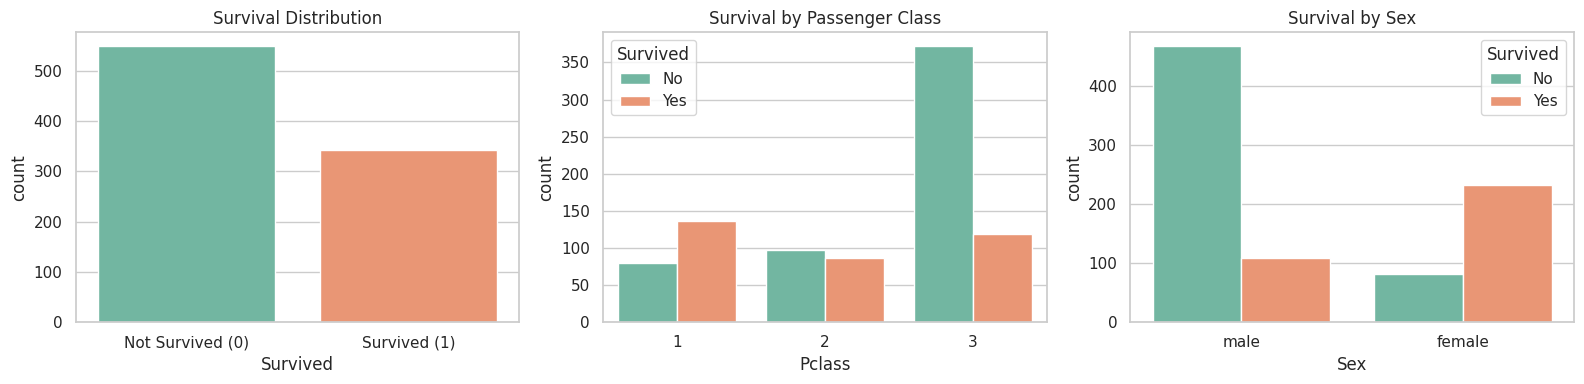

In [30]:
# Cell 7
# 1. Survival count
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Survival distribution
sns.countplot(x='Survived', data=train_data, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Distribution')
axes[0].set_xticklabels(['Not Survived (0)', 'Survived (1)'])

# Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=train_data, ax=axes[1], palette='Set2')
axes[1].set_title('Survival by Passenger Class')
axes[1].legend(title='Survived', labels=['No', 'Yes'])

# Survival by Sex
sns.countplot(x='Sex', hue='Survived', data=train_data, ax=axes[2], palette='Set2')
axes[2].set_title('Survival by Sex')
axes[2].legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

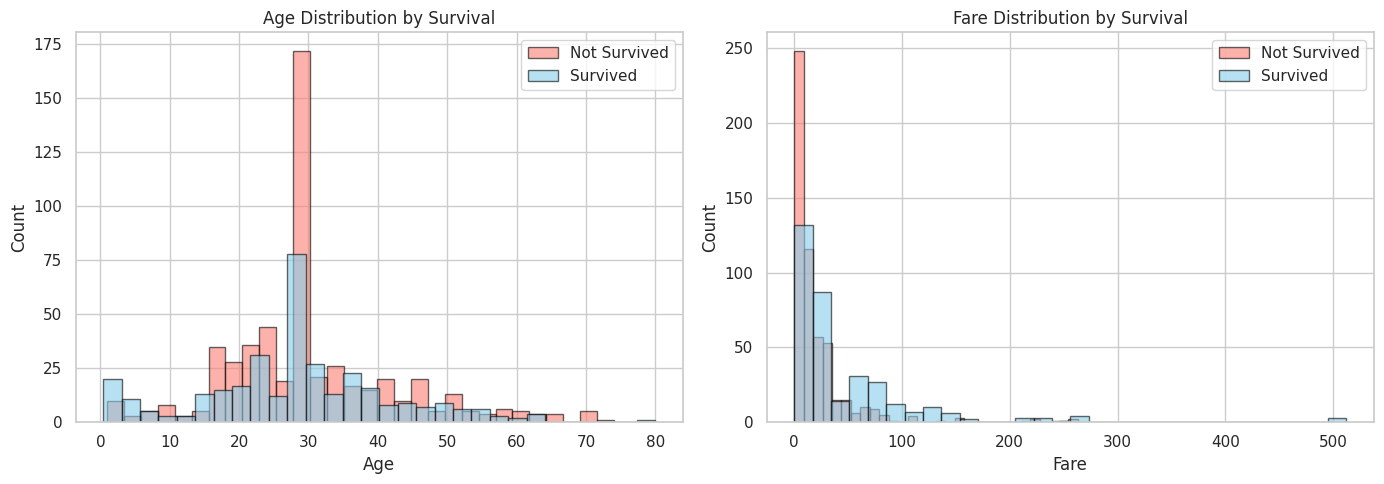

In [31]:
# Cell 8
# 2. Age distribution by survival
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution histogram
axes[0].hist(train_data[train_data['Survived']==0]['Age'], bins=30, alpha=0.6, label='Not Survived', color='salmon', edgecolor='black')
axes[0].hist(train_data[train_data['Survived']==1]['Age'], bins=30, alpha=0.6, label='Survived', color='skyblue', edgecolor='black')
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Fare distribution by survival
axes[1].hist(train_data[train_data['Survived']==0]['Fare'], bins=30, alpha=0.6, label='Not Survived', color='salmon', edgecolor='black')
axes[1].hist(train_data[train_data['Survived']==1]['Fare'], bins=30, alpha=0.6, label='Survived', color='skyblue', edgecolor='black')
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

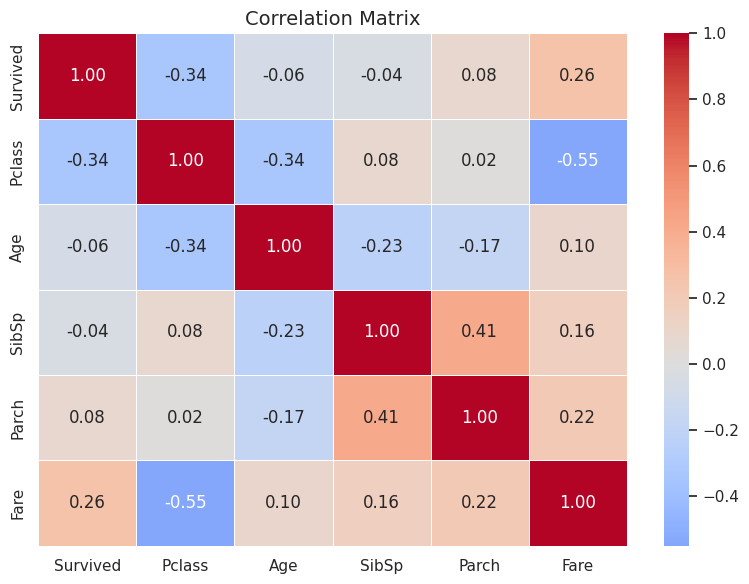

In [32]:
# Cell 9
# 3. Correlation heatmap of numeric features
plt.figure(figsize=(8, 6))
corr = train_data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
# Cell 10
# Encode 'Sex': female=0, male=1
le_sex = LabelEncoder()
train_data['Sex'] = le_sex.fit_transform(train_data['Sex'])
print(f'Sex encoding: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}')

# One-Hot encode 'Embarked' (drop_first avoids multicollinearity)
train_data = pd.get_dummies(train_data, columns=['Embarked'], drop_first=True, dtype=int)

print(f'\nColumns after encoding: {list(train_data.columns)}')
train_data.head()

Sex encoding: {'female': np.int64(0), 'male': np.int64(1)}

Columns after encoding: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


Training: 712 samples  |  Test: 179 samples


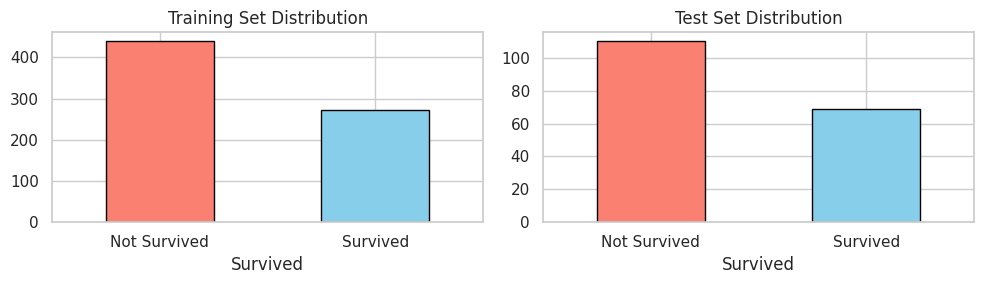

In [34]:
# Cell 11
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')

# Visualize the split proportions
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
y_train.value_counts().plot.bar(ax=axes[0], color=['salmon', 'skyblue'], edgecolor='black')
axes[0].set_title('Training Set Distribution')
axes[0].set_xticklabels(['Not Survived', 'Survived'], rotation=0)

y_test.value_counts().plot.bar(ax=axes[1], color=['salmon', 'skyblue'], edgecolor='black')
axes[1].set_title('Test Set Distribution')
axes[1].set_xticklabels(['Not Survived', 'Survived'], rotation=0)

plt.tight_layout()
plt.show()

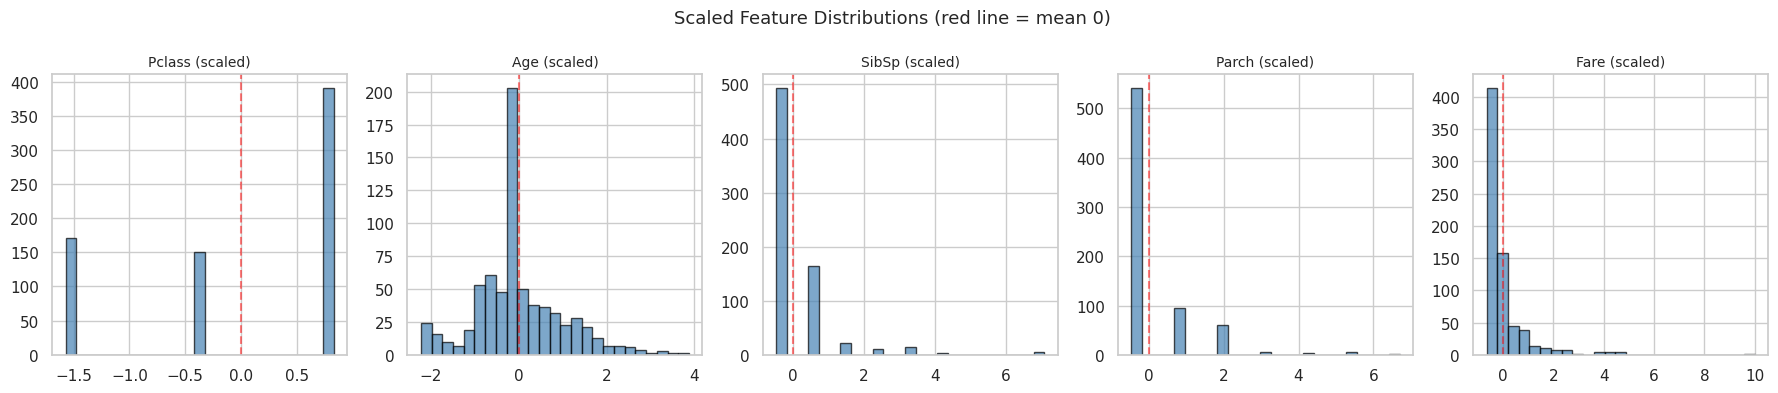

In [35]:
# Cell 12
numerical_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
scaler = StandardScaler()

# fit_transform on train, transform on test (prevents leakage)
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Visualize distributions before vs after scaling
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(18, 4))
for i, col in enumerate(numerical_cols):
    axes[i].hist(X_train[col], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} (scaled)', fontsize=10)
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
plt.suptitle('Scaled Feature Distributions (red line = mean 0)', fontsize=13)
plt.tight_layout()
plt.show()

Model trained successfully!


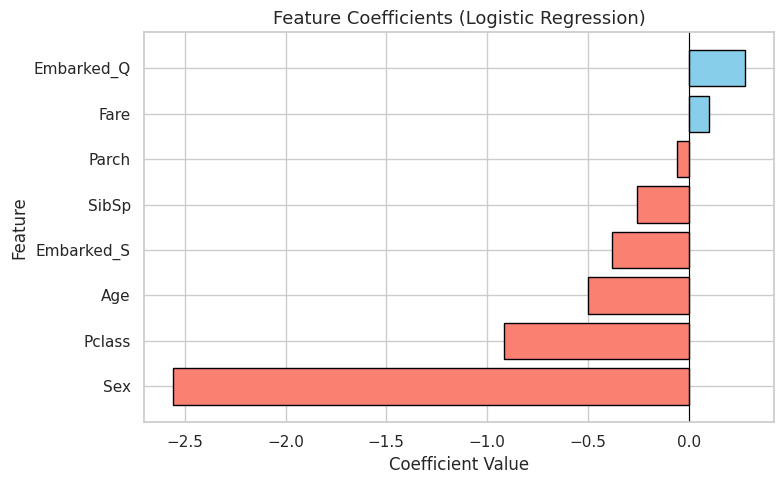


Interpretation:
  Positive coefficient → increases survival probability
  Negative coefficient → decreases survival probability


In [36]:
# Cell 13
# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print('Model trained successfully!')

# Visualize feature coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')

plt.figure(figsize=(8, 5))
colors = ['salmon' if c < 0 else 'skyblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients (Logistic Regression)', fontsize=13)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  Positive coefficient → increases survival probability')
print('  Negative coefficient → decreases survival probability')

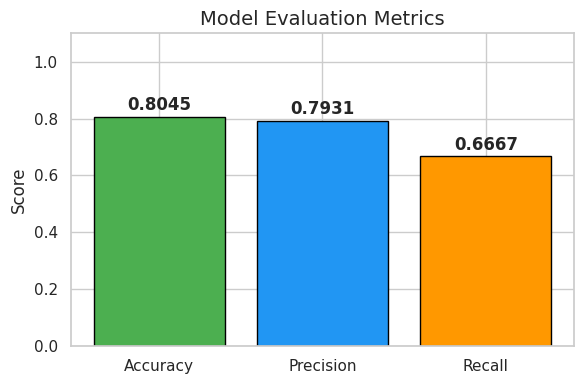

In [37]:
# Cell 14
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

# Visualize metrics as a bar chart
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall}
plt.figure(figsize=(6, 4))
bars = plt.bar(metrics.keys(), metrics.values(), color=['#4CAF50', '#2196F3', '#FF9800'], edgecolor='black')
for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.ylim(0, 1.1)
plt.title('Model Evaluation Metrics', fontsize=14)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

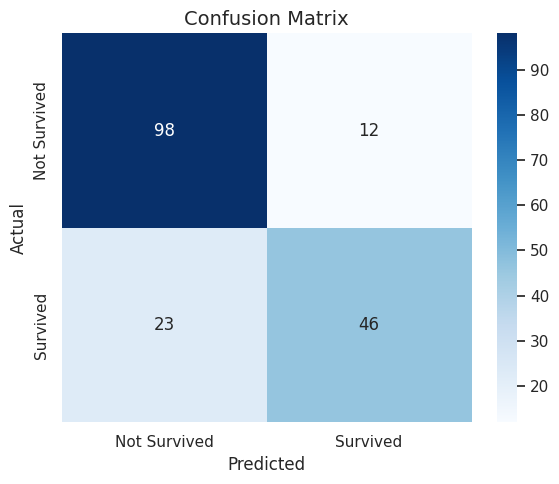

True Negatives:  98  |  False Positives: 12
False Negatives: 23  |  True Positives:  46


In [38]:
# Cell 15
# Confusion Matrix visualization
# Rows = Actual, Columns = Predicted
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f'True Negatives:  {cm[0][0]}  |  False Positives: {cm[0][1]}')
print(f'False Negatives: {cm[1][0]}  |  True Positives:  {cm[1][1]}')

In [39]:
# Cell 16
# Full Classification Report
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

              precision    recall  f1-score   support

Not Survived       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [40]:
# Cell 18
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
import joblib

RANDOM_STATE = 42


In [41]:
# Cell 19
# Step 1: Load raw data and create train/test split
raw_df = pd.read_csv('train.csv')
X_raw = raw_df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
y_raw = raw_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE, stratify=y_raw
)

# 5-fold CV object for stability checks and grid-search
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [42]:
# Cell 20
# Step 2: Manual preprocessing baseline (outside pipeline)
manual_df = raw_df.copy()
manual_df['Age'] = manual_df['Age'].fillna(manual_df['Age'].median())
manual_df['Embarked'] = manual_df['Embarked'].fillna(manual_df['Embarked'].mode()[0])
manual_df = manual_df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

# Manual categorical encoding
manual_le = LabelEncoder()
manual_df['Sex'] = manual_le.fit_transform(manual_df['Sex'])
manual_df = pd.get_dummies(manual_df, columns=['Embarked'], drop_first=True, dtype=int)

X_manual = manual_df.drop(columns=['Survived'])
y_manual = manual_df['Survived']

# Manual scaling on numeric features
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
manual_scaler = StandardScaler()
X_manual_scaled = X_manual.copy()
X_manual_scaled[num_cols] = manual_scaler.fit_transform(X_manual_scaled[num_cols])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_manual_scaled, y_manual, test_size=0.2, random_state=RANDOM_STATE, stratify=y_manual
)

manual_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
manual_model.fit(X_train_m, y_train_m)
manual_pred = manual_model.predict(X_test_m)
manual_proba = manual_model.predict_proba(X_test_m)[:, 1]

manual_train_acc = manual_model.score(X_train_m, y_train_m)
manual_test_acc = accuracy_score(y_test_m, manual_pred)
manual_roc_auc = roc_auc_score(y_test_m, manual_proba)
manual_cv_scores = cross_val_score(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_manual_scaled,
    y_manual,
    cv=cv5,
    scoring='accuracy'
)

print(f'Manual Train Accuracy: {manual_train_acc:.4f}')
print(f'Manual Test Accuracy:  {manual_test_acc:.4f}')
print(f'Manual ROC-AUC:        {manual_roc_auc:.4f}')
print(f'Manual CV (5-fold):    {manual_cv_scores.mean():.4f} +/- {manual_cv_scores.std():.4f}')


Manual Train Accuracy: 0.8076
Manual Test Accuracy:  0.8045
Manual ROC-AUC:        0.8436
Manual CV (5-fold):    0.7924 +/- 0.0174


In [43]:
# Cell 21
# Step 3 + 4: ColumnTransformer + Pipeline
# Numerical -> imputation + scaling
numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical -> imputation + one-hot encoding
categorical_features = ['Sex', 'Embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine both preprocessors
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Baseline model pipeline
baseline_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

baseline_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [44]:
# Cell 22
# Step 5 + 6: Baseline evaluation + CV stability
baseline_train_acc = baseline_pipe.score(X_train, y_train)
baseline_pred = baseline_pipe.predict(X_test)
baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]
baseline_test_acc = accuracy_score(y_test, baseline_pred)
baseline_roc_auc = roc_auc_score(y_test, baseline_proba)
baseline_cm = confusion_matrix(y_test, baseline_pred)

baseline_cv_scores = cross_val_score(baseline_pipe, X_train, y_train, cv=cv5, scoring='accuracy')

print(f'Baseline Train Accuracy: {baseline_train_acc:.4f}')
print(f'Baseline Test Accuracy:  {baseline_test_acc:.4f}')
print(f'Baseline ROC-AUC:        {baseline_roc_auc:.4f}')
print(f'Baseline CV (5-fold):    {baseline_cv_scores.mean():.4f} +/- {baseline_cv_scores.std():.4f}')


Baseline Train Accuracy: 0.8076
Baseline Test Accuracy:  0.8045
Baseline ROC-AUC:        0.8435
Baseline CV (5-fold):    0.7949 +/- 0.0273


In [45]:
# Cell 23
# Step 7: Advanced tuning with GridSearchCV (tune 2 hyperparameters)
param_grid = {
    # preprocessing hyperparameter
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    # model hyperparameter
    'classifier__C': [0.1, 1.0, 10.0],
}

grid = GridSearchCV(
    estimator=baseline_pipe,
    param_grid=param_grid,
    cv=cv5,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True,
)

grid.fit(X_train, y_train)
best_pipe = grid.best_estimator_

tuned_train_acc = best_pipe.score(X_train, y_train)
tuned_pred = best_pipe.predict(X_test)
tuned_proba = best_pipe.predict_proba(X_test)[:, 1]
tuned_test_acc = accuracy_score(y_test, tuned_pred)
tuned_roc_auc = roc_auc_score(y_test, tuned_proba)
tuned_cm = confusion_matrix(y_test, tuned_pred)
tuned_cv_scores = cross_val_score(best_pipe, X_train, y_train, cv=cv5, scoring='accuracy')

print('Best Params:', grid.best_params_)
print(f'Best CV ROC-AUC:         {grid.best_score_:.4f}')
print(f'Tuned Train Accuracy:    {tuned_train_acc:.4f}')
print(f'Tuned Test Accuracy:     {tuned_test_acc:.4f}')
print(f'Tuned ROC-AUC:           {tuned_roc_auc:.4f}')
print(f'Tuned CV (5-fold):       {tuned_cv_scores.mean():.4f} +/- {tuned_cv_scores.std():.4f}')


Best Params: {'classifier__C': 1.0, 'preprocessor__num__imputer__strategy': 'mean'}
Best CV ROC-AUC:         0.8551
Tuned Train Accuracy:    0.8048
Tuned Test Accuracy:     0.8045
Tuned ROC-AUC:           0.8433
Tuned CV (5-fold):       0.7963 +/- 0.0278


In [46]:
# Cell 24
# Step 8: Compare manual vs baseline vs tuned
comparison_df = pd.DataFrame({
    'Model': ['Manual', 'Baseline Pipeline', 'Tuned Pipeline'],
    'Train Accuracy': [manual_train_acc, baseline_train_acc, tuned_train_acc],
    'CV Mean Accuracy': [manual_cv_scores.mean(), baseline_cv_scores.mean(), tuned_cv_scores.mean()],
    'CV Std': [manual_cv_scores.std(), baseline_cv_scores.std(), tuned_cv_scores.std()],
    'Test Accuracy': [manual_test_acc, baseline_test_acc, tuned_test_acc],
    'Test ROC-AUC': [manual_roc_auc, baseline_roc_auc, tuned_roc_auc],
})

comparison_df


,Model,Train Accuracy,CV Mean Accuracy,CV Std,Test Accuracy,Test ROC-AUC
0,Manual,0.807584,0.792392,0.017445,0.804469,0.843610
1,Baseline Pipeline,0.807584,0.794937,0.027277,0.804469,0.843478
2,Tuned Pipeline,0.804775,0.796346,0.027823,0.804469,0.843347


In [47]:
# Cell 25
# Step 8 (continued): Stability + bias/variance interpretation
def interpret_stability(cv_mean, cv_std, test_acc):
    gap = abs(cv_mean - test_acc)
    if cv_std <= 0.03 and gap <= 0.03:
        return 'Stable: CV mean and test score are close with low fold variance.'
    if cv_std <= 0.05 and gap <= 0.05:
        return 'Moderately stable: some variation across folds but acceptable.'
    return 'Less stable: high fold variance or larger CV-test gap.'


def bias_variance_note(train_acc, test_acc, cv_std):
    if train_acc - test_acc > 0.07:
        return 'Variance-heavy behavior (possible overfitting).'
    if train_acc < 0.78 and test_acc < 0.78:
        return 'Bias-heavy behavior (possible underfitting).'
    if cv_std > 0.05:
        return 'Notable variance across folds.'
    return 'Bias-variance trade-off appears balanced.'

print('Manual Stability:  ', interpret_stability(manual_cv_scores.mean(), manual_cv_scores.std(), manual_test_acc))
print('Baseline Stability:', interpret_stability(baseline_cv_scores.mean(), baseline_cv_scores.std(), baseline_test_acc))
print('Tuned Stability:   ', interpret_stability(tuned_cv_scores.mean(), tuned_cv_scores.std(), tuned_test_acc))

print('Manual Bias/Variance:  ', bias_variance_note(manual_train_acc, manual_test_acc, manual_cv_scores.std()))
print('Baseline Bias/Variance:', bias_variance_note(baseline_train_acc, baseline_test_acc, baseline_cv_scores.std()))
print('Tuned Bias/Variance:   ', bias_variance_note(tuned_train_acc, tuned_test_acc, tuned_cv_scores.std()))


Manual Stability:   Stable: CV mean and test score are close with low fold variance.
Baseline Stability: Stable: CV mean and test score are close with low fold variance.
Tuned Stability:    Stable: CV mean and test score are close with low fold variance.
Manual Bias/Variance:   Bias-variance trade-off appears balanced.
Baseline Bias/Variance: Bias-variance trade-off appears balanced.
Tuned Bias/Variance:    Bias-variance trade-off appears balanced.


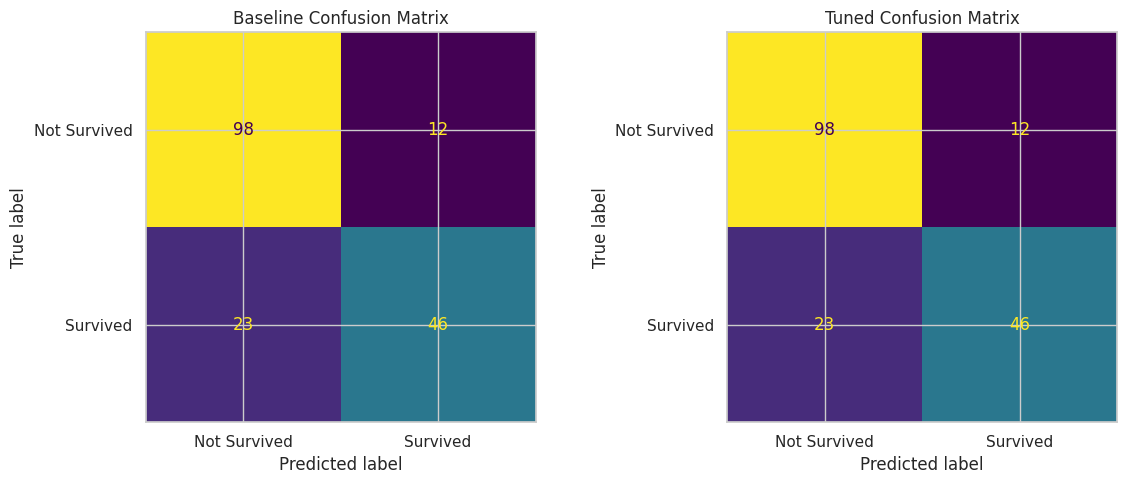

<Figure size 700x600 with 0 Axes>

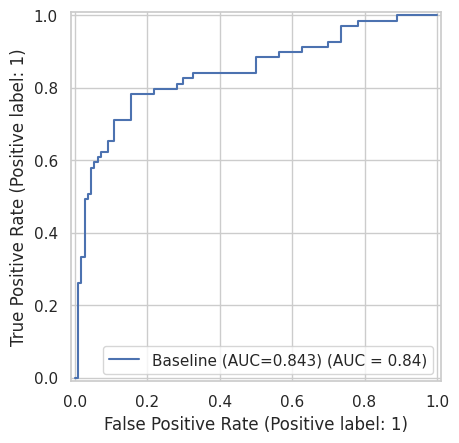

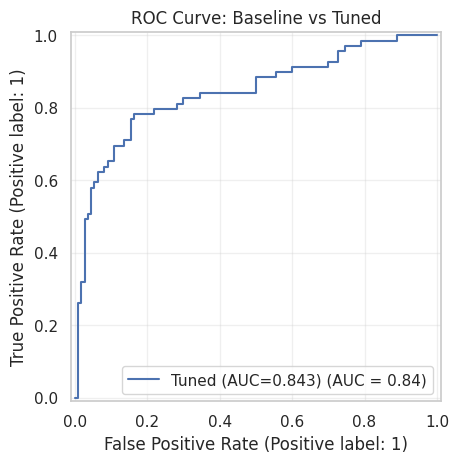

In [48]:
# Cell 26
# Step 5 (visual): Confusion matrix and ROC-AUC plots for baseline vs tuned
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=baseline_cm, display_labels=['Not Survived', 'Survived']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Baseline Confusion Matrix')

ConfusionMatrixDisplay(confusion_matrix=tuned_cm, display_labels=['Not Survived', 'Survived']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Tuned Confusion Matrix')

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, baseline_proba, name=f'Baseline (AUC={baseline_roc_auc:.3f})')
RocCurveDisplay.from_predictions(y_test, tuned_proba, name=f'Tuned (AUC={tuned_roc_auc:.3f})')
plt.title('ROC Curve: Baseline vs Tuned')
plt.grid(alpha=0.3)
plt.show()


In [49]:
# Cell 27
# Step 9: Save tuned end-to-end pipeline
joblib.dump(best_pipe, 'titanic_best_pipeline.joblib')
print('Saved:', 'titanic_best_pipeline.joblib')


Saved: titanic_best_pipeline.joblib
